In [530]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [531]:
#En caso de no poder cargar el archivo con seaborns leerlo con pandas
df= pd.read_csv("Base_resumen.csv", header=[5])

In [532]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Año                           4 non-null      str    
 1   Mes                           42 non-null     str    
 2   Leads                         39 non-null     str    
 3   Efectivos                     39 non-null     str    
 4   Ventas Reportadas             39 non-null     float64
 5   Obj Ventas                    30 non-null     float64
 6   Ventas Real                   39 non-null     float64
 7   % CAL                         30 non-null     str    
 8   Obj Conversion                30 non-null     str    
 9   Conversion                    39 non-null     str    
 10  % CAL                         30 non-null     str    
 11  Obj UN                        7 non-null      str    
 12  UN                            6 non-null      str    
 13  %  CAL            

In [533]:
df.columns

Index(['Año', 'Mes ', 'Leads', 'Efectivos ', 'Ventas Reportadas', 'Obj Ventas',
       'Ventas Real ', '% CAL', 'Obj Conversion ', 'Conversion ', '% CAL   ',
       'Obj UN', 'UN', '%  CAL  ', 'Obj SDC', 'SDC', '%  CAL    ',
       'Autorizadas ', 'Formalizado', 'Contado', 'Credito', '% Autorizadas',
       '% Formalizadas', 'Obj PDM ', 'PDM ', ' %  CAL',
       '% / Conversion Venta- PDM ', 'Variacion', 'Lead / Venta ', 'Flotillas',
       'RDC', 'Obj Marca', 'Cumpliento', '% Formalizadas / Autorizadas',
       'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37',
       'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41',
       'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45',
       'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49',
       'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53',
       'Unnamed: 54', 'Unnamed: 55', 'Proyeccion', 'Diferencia', 'Unnamed: 58',
       'Unnamed: 59', 'Unnamed: 60'],
      dtype='str')

In [534]:
# Limpieza antes de empezar
df.columns = df.columns.str.strip()
df.columns.values[7]  = '% CAL Ventas'      
df.columns.values[10] = '% CAL Conversion'           
df.columns.values[16] = '% CAL SDC'
df.columns.values[25] = '% CAL PDM' 

df["Año"] = df["Año"].replace("", pd.NA).ffill()
df = df.iloc[:30]
df = df.iloc[:, :29]
df = df.drop(df.columns[11:14], axis=1)

In [535]:
df.columns

Index(['Año', 'Mes', 'Leads', 'Efectivos', 'Ventas Reportadas', 'Obj Ventas',
       'Ventas Real', '% CAL Ventas', 'Obj Conversion', 'Conversion',
       '% CAL Conversion', 'Obj SDC', 'SDC', '% CAL SDC', 'Autorizadas',
       'Formalizado', 'Contado', 'Credito', '% Autorizadas', '% Formalizadas',
       'Obj PDM', 'PDM', '% CAL PDM', '% / Conversion Venta- PDM', 'Variacion',
       'Lead / Venta'],
      dtype='str')

In [536]:
# Correción tipos de datos
cols_int = ["Año", "Leads", "Efectivos", "Ventas Reportadas", "Obj Ventas", "Ventas Real", "Obj SDC", "SDC", "Autorizadas", "Formalizado", "Contado", "Credito",
            "Obj PDM", "PDM"]

df[cols_int] = df[cols_int].replace(",", "", regex=True).astype("Int64")

In [537]:
# Columnas %
df["Variacion"] = df["Variacion"].replace('-', '0')
pct_cols = ["% CAL Ventas", "Obj Conversion", "Conversion", "% CAL Conversion", "% CAL SDC", "% Autorizadas", "% Formalizadas", "% CAL PDM", "% / Conversion Venta- PDM", "Variacion"]

df[pct_cols] = df[pct_cols].replace('%', '', regex=True).astype(float) / 100

In [538]:
# Remplazar por valores numéricos la columna de "Mes"
meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df["Mes"] = df["Mes"].str.strip().replace(meses).astype(int)

In [539]:
# Verificar otra vez
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Año                        30 non-null     Int64  
 1   Mes                        30 non-null     int64  
 2   Leads                      30 non-null     Int64  
 3   Efectivos                  30 non-null     Int64  
 4   Ventas Reportadas          30 non-null     Int64  
 5   Obj Ventas                 30 non-null     Int64  
 6   Ventas Real                30 non-null     Int64  
 7   % CAL Ventas               30 non-null     float64
 8   Obj Conversion             30 non-null     float64
 9   Conversion                 30 non-null     float64
 10  % CAL Conversion           30 non-null     float64
 11  Obj SDC                    30 non-null     Int64  
 12  SDC                        30 non-null     Int64  
 13  % CAL SDC                  30 non-null     float64
 14  Autoriz

In [540]:
# Guardar el DataFrame limpio en un nuevo archivo CSV
df.to_csv("base_resumen_limpio.csv", index=False)

In [541]:
df2 = df[["Leads", "Efectivos", "Ventas Real", "Obj SDC", "SDC", "Autorizadas", "Formalizado", "Contado", "Credito"]]

<Axes: xlabel='SDC', ylabel='Formalizado'>

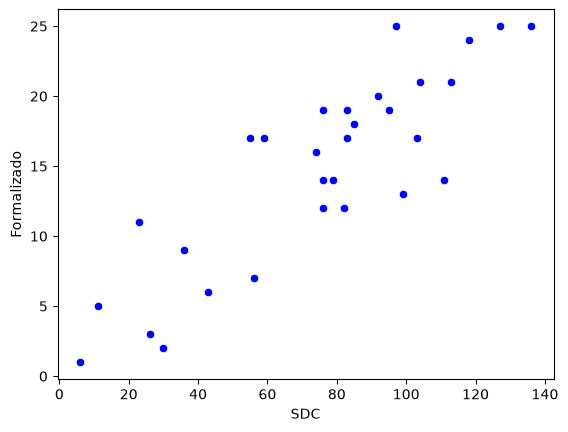

In [542]:
#Imprimimos el scatter plot entre la variable dependiente (total) e independiente (efectivos) 
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='SDC', y='Formalizado', color="blue", data=df2)

In [543]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df2[['SDC']]
Var_Dep= df2['Formalizado']

In [544]:
# Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [545]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.17]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['SDC']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.778
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [546]:
# Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['SDC'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.17286982]),
 'rank_': np.int64(1),
 'singular_': array([185.02288147]),
 'intercept_': np.float64(1.778380610007364)}

In [547]:
# Modelo matemático:
# y= 0.17286982(SDC)+1.778380610007364

In [548]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.7405941624860517

In [549]:
#Predecimos los valores de formalizado a partir de la variable "SDC"
y_pred= model.predict(X=df2[['SDC']])
y_pred

array([ 2.81559955,  3.67994867,  5.75438655,  6.27299602,  9.21178301,
       11.28622089,  8.00169425, 11.45909071, 15.43509665, 14.91648718,
       19.58397241, 16.12657594, 14.91648718, 17.68240435, 11.97770018,
       14.91648718, 18.54675347, 19.75684223, 18.89249312, 23.73284817,
       25.28867658, 22.17701976, 20.966931  , 21.31267064, 16.12657594,
       16.47231559, 14.57074753, 18.20101382, 15.95370612,  6.96447531])

In [550]:
# Insertamos la columna de predicciones en el DataFrame
df2.insert(5, 'Predicciones', y_pred)
df2

,Leads,Efectivos,Ventas Real,Obj SDC,SDC,Predicciones,Autorizadas,Formalizado,Contado,Credito
0,543,389,12,10,6,2.815600,2,1,10,1
1,178,128,7,10,11,3.679949,7,5,4,3
2,416,288,8,15,23,5.754387,14,11,2,6
3,422,274,13,15,26,6.272996,8,3,3,10
4,967,620,6,25,43,9.211783,13,6,0,6
5,954,570,21,35,55,11.286221,30,17,7,14
6,1409,546,17,35,36,8.001694,19,9,2,15
7,1315,530,17,40,56,11.459091,26,7,6,11
8,1973,822,23,70,79,15.435097,31,14,2,21
9,1562,1040,22,75,76,14.916487,25,14,4,18


<Axes: xlabel='SDC', ylabel='Formalizado'>

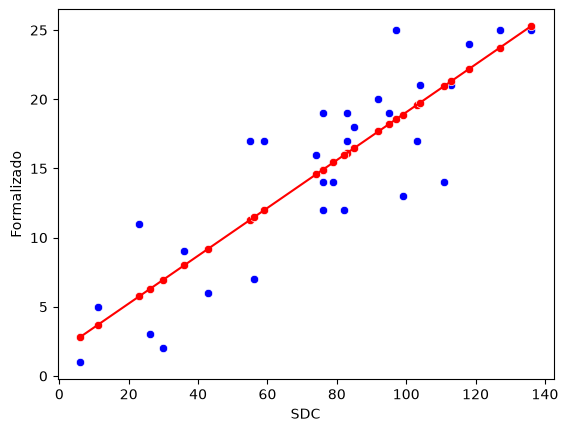

In [551]:
#Visualizamos la gráfica comparativa entre el total real y el total predecido

sns.scatterplot(x='SDC', y='Formalizado', color="blue", data=df2)
sns.scatterplot(x='SDC', y='Predicciones', color="red", data=df2)
sns.lineplot(x='SDC', y='Predicciones', color="red", data=df2)

In [552]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.7405941624860517

In [553]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.860577807339959)

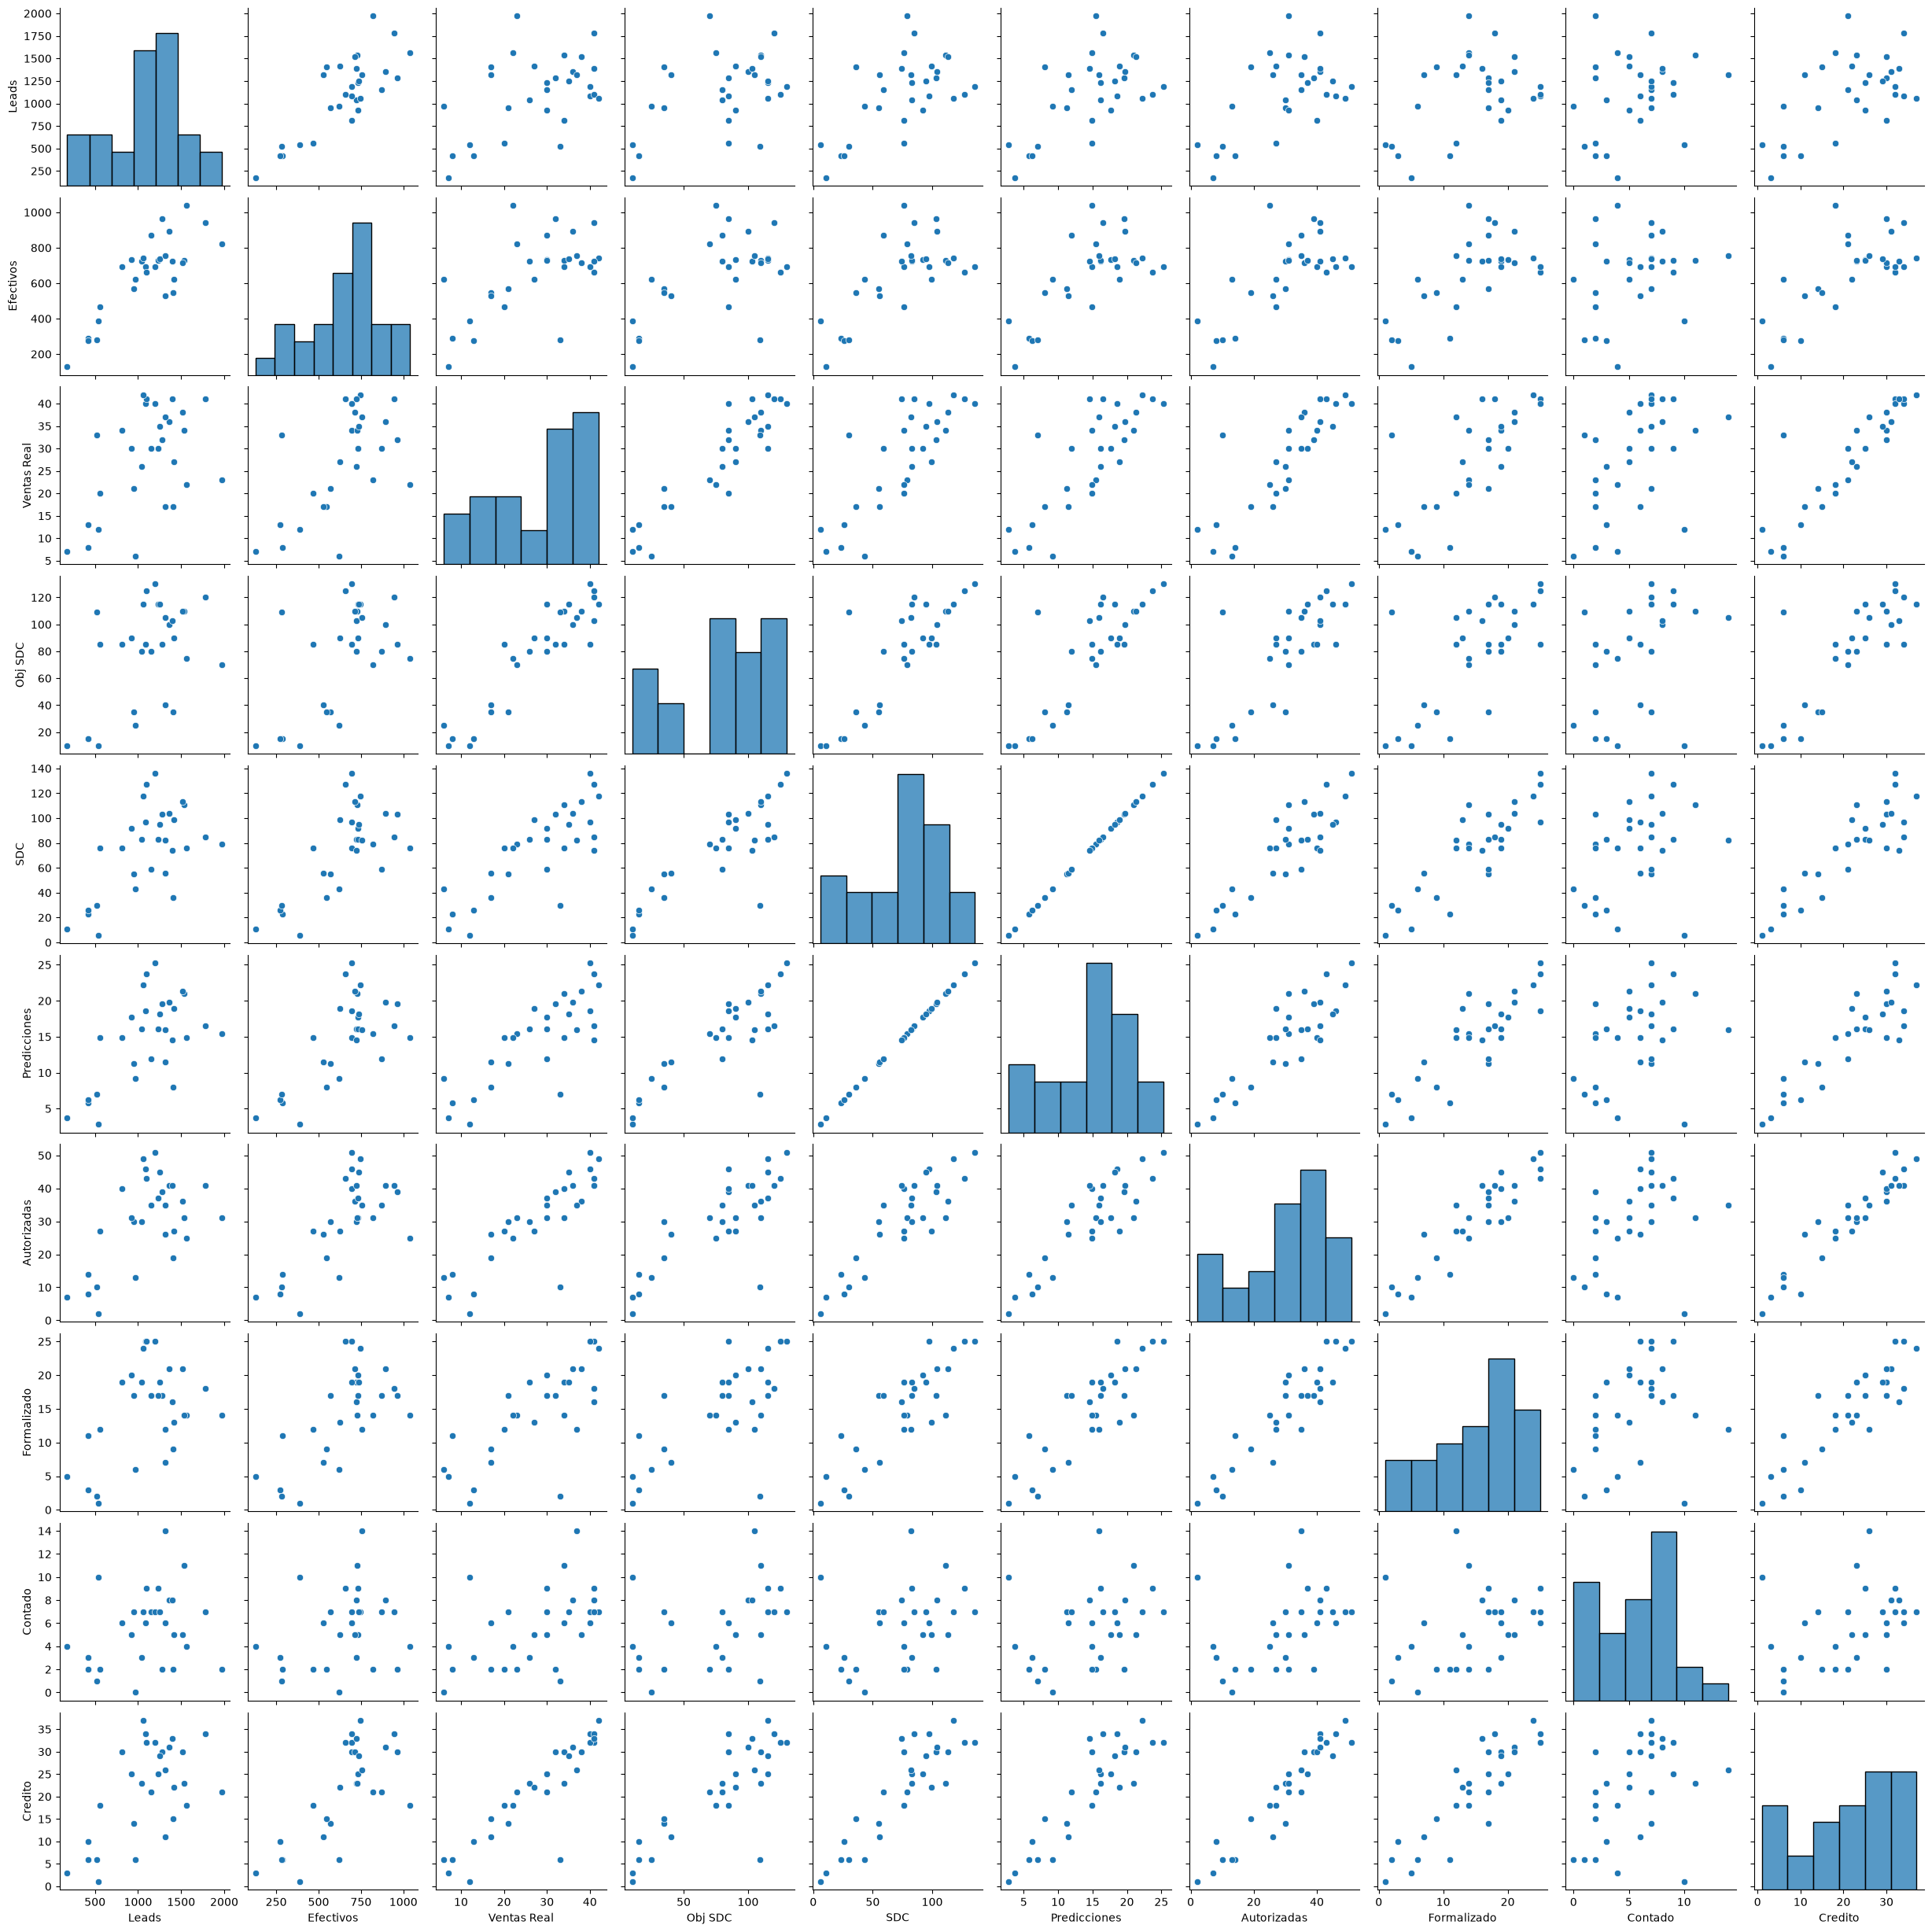

In [554]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df2)

In [555]:
#Encontramos todas las correlaciones entre las variables 
Corr_Factors=df2.corr()
Corr_Factors

,Leads,Efectivos,Ventas Real,Obj SDC,SDC,Predicciones,Autorizadas,Formalizado,Contado,Credito
Leads,1.000000,0.809103,0.497176,0.512242,0.591564,0.591564,0.567387,0.439680,0.245954,0.579861
Efectivos,0.809103,1.000000,0.600694,0.599361,0.687552,0.687552,0.715662,0.647969,0.271032,0.726229
Ventas Real,0.497176,0.600694,1.000000,0.921810,0.803614,0.803614,0.855222,0.756545,0.499711,0.899619
Obj SDC,0.512242,0.599361,0.921810,1.000000,0.840350,0.840350,0.798360,0.695436,0.401082,0.823835
SDC,0.591564,0.687552,0.803614,0.840350,1.000000,1.000000,0.880765,0.860578,0.346054,0.883199
Predicciones,0.591564,0.687552,0.803614,0.840350,1.000000,1.000000,0.880765,0.860578,0.346054,0.883199
Autorizadas,0.567387,0.715662,0.855222,0.798360,0.880765,0.880765,1.000000,0.919922,0.413551,0.951793
Formalizado,0.439680,0.647969,0.756545,0.695436,0.860578,0.860578,0.919922,1.000000,0.303643,0.890035
Contado,0.245954,0.271032,0.499711,0.401082,0.346054,0.346054,0.413551,0.303643,1.000000,0.393898
Credito,0.579861,0.726229,0.899619,0.823835,0.883199,0.883199,0.951793,0.890035,0.393898,1.000000


<Axes: >

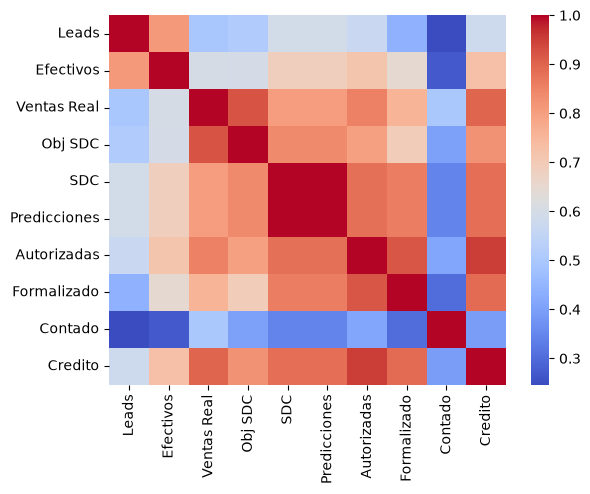

In [556]:
#Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors, cmap = 'coolwarm')  
Heat_Map

<Axes: >

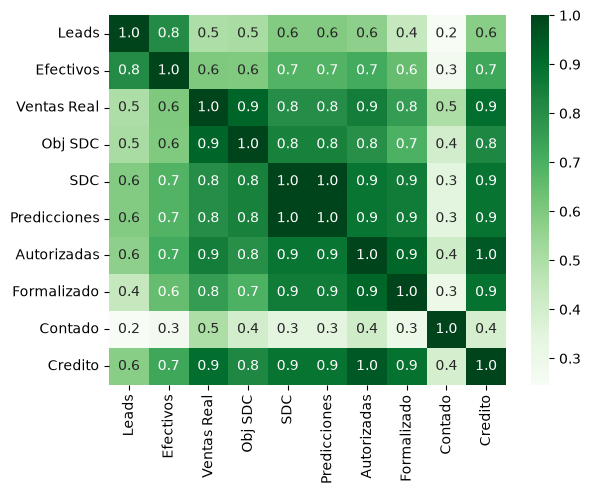

In [557]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map